In [1]:
import pandas as pd

# Load the Health Index data
health = pd.read_excel('healthindexscoresengland.xlsx', sheet_name=None)
print("Health Index sheets found:")
for sheet_name in health.keys():
    print(f" - {sheet_name}")

# Load the Deprivation data
deprivation = pd.read_excel('File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx', sheet_name=None)
print("\nDeprivation sheets found:")
for sheet_name in deprivation.keys():
    print(f" - {sheet_name}")

Health Index sheets found:
 - Cover_sheet
 - Table_of_Contents
 - Notes
 - Table_1_Indicator_details
 - Table_2_Index_scores
 - Table_3_2021_Index
 - Table_4_2020_Index
 - Table_5_2019_Index
 - Table_6_2018_Index
 - Table_7_2017_Index
 - Table_8_2016_Index
 - Table_9_2015_Index
 - Table_10_IMD_quintile

Deprivation sheets found:
 - Notes
 - IMD
 - Income
 - Employment
 - Education
 - Health
 - Crime
 - Barriers
 - Living
 - IDACI
 - IDAOPI


In [25]:
# Look at the Health Index scores table
health_scores = health['Table_2_Index_scores']
print(health_scores.head(10))
print("\nColumns:", health_scores.columns.tolist())
print("\nShape:", health_scores.shape)

  Table 2. Overall Health Index scores, 2015 to 2021            Unnamed: 1  \
0  This worksheet contains one table. Some cells ...                   NaN   
1                                          Area Code             Area Name   
2                                          E92000001               ENGLAND   
3                                          E12000001            North East   
4                                          E06000001            Hartlepool   
5                                          E06000002         Middlesbrough   
6                                          E06000003  Redcar and Cleveland   
7                                          E06000004      Stockton-on-Tees   
8                                          E06000005            Darlington   
9                                          E06000047         County Durham   

           Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  \
0                 NaN         NaN         NaN         NaN         Na

In [26]:
# Look at the IMD deprivation table
imd = deprivation['IMD']
print(imd.head(10))
print("\nColumns:", imd.columns.tolist())
print("\nShape:", imd.shape)

  Local Authority District code (2019) Local Authority District name (2019)  \
0                            E06000001                           Hartlepool   
1                            E06000002                        Middlesbrough   
2                            E06000003                 Redcar and Cleveland   
3                            E06000004                     Stockton-on-Tees   
4                            E06000005                           Darlington   
5                            E06000006                               Halton   
6                            E06000007                           Warrington   
7                            E06000008                Blackburn with Darwen   
8                            E06000009                            Blackpool   
9                            E06000010          Kingston upon Hull, City of   

   IMD - Average rank   IMD - Rank of average rank   IMD - Average score   \
0             22581.98                           25  

**DATA CLEANING**

In [27]:
health_clean = pd.read_excel('healthindexscoresengland.xlsx', sheet_name='Table_2_Index_scores', header=2)

health_clean = health_clean.rename(columns={
    'Area Code': 'area_code',
    'Area Name': 'area_name',
    'Area Type [Note 3]': 'area_type'
})

health_clean = health_clean[health_clean['area_type'] == 'LTLA'].copy()

print(health_clean.shape)
print(health_clean.columns.tolist())
health_clean.head()

(307, 10)
['area_code', 'area_name', 'area_type', '2015', '2016', '2017', '2018', '2019', '2020', '2021']


,area_code,area_name,area_type,2015,2016,2017,2018,2019,2020,2021
2,E06000001,Hartlepool,LTLA,88.3,88.5,86.3,85.6,85.4,87.3,87.2
3,E06000002,Middlesbrough,LTLA,83.3,82.5,82.7,80.9,79.7,79.1,80.2
4,E06000003,Redcar and Cleveland,LTLA,96.6,98.0,97.9,96.2,95.7,92.1,92.5
5,E06000004,Stockton-on-Tees,LTLA,92.2,94.1,93.1,92.1,95.1,96.1,94.8
6,E06000005,Darlington,LTLA,96.4,95.3,95.1,96.3,98.2,94.8,94.7


(307, 10)
['area_code', 'area_name', 'area_type', '2015', '2016', '2017', '2018', '2019', '2020', '2021']


,area_code,area_name,area_type,2015,2016,2017,2018,2019,2020,2021
2,E06000001,Hartlepool,LTLA,88.3,88.5,86.3,85.6,85.4,87.3,87.2
3,E06000002,Middlesbrough,LTLA,83.3,82.5,82.7,80.9,79.7,79.1,80.2
4,E06000003,Redcar and Cleveland,LTLA,96.6,98.0,97.9,96.2,95.7,92.1,92.5
5,E06000004,Stockton-on-Tees,LTLA,92.2,94.1,93.1,92.1,95.1,96.1,94.8
6,E06000005,Darlington,LTLA,96.4,95.3,95.1,96.3,98.2,94.8,94.7


In [28]:
imd_clean = imd.rename(columns={
    'Local Authority District code (2019)': 'area_code',
    'Local Authority District name (2019)': 'area_name',
    'IMD - Average score ': 'imd_avg_score',
    'IMD - Average rank ': 'imd_avg_rank',
    'IMD - Proportion of LSOAs in most deprived 10% nationally ': 'imd_pct_most_deprived'
})[['area_code', 'area_name', 'imd_avg_score', 'imd_avg_rank', 'imd_pct_most_deprived']]

print(imd_clean.shape)
imd_clean.head()

(317, 5)


,area_code,area_name,imd_avg_score,imd_avg_rank,imd_pct_most_deprived
0,E06000001,Hartlepool,35.037,22581.98,0.3621
1,E06000002,Middlesbrough,40.460,23729.10,0.4884
2,E06000003,Redcar and Cleveland,29.792,20348.40,0.2386
3,E06000004,Stockton-on-Tees,25.790,17541.72,0.2083
4,E06000005,Darlington,25.657,18284.63,0.1846


(317, 5)


,area_code,area_name,imd_avg_score,imd_avg_rank,imd_pct_most_deprived
0,E06000001,Hartlepool,35.037,22581.98,0.3621
1,E06000002,Middlesbrough,40.460,23729.10,0.4884
2,E06000003,Redcar and Cleveland,29.792,20348.40,0.2386
3,E06000004,Stockton-on-Tees,25.790,17541.72,0.2083
4,E06000005,Darlington,25.657,18284.63,0.1846


In [29]:
merged = pd.merge(health_clean, imd_clean, on='area_code', how='inner', suffixes=('_health', '_imd'))

print("Merged shape:", merged.shape)
print("Health rows:", health_clean.shape[0], "| Deprivation rows:", imd_clean.shape[0])
merged.head()

Merged shape: (304, 14)
Health rows: 307 | Deprivation rows: 317


,area_code,area_name_health,area_type,2015,2016,2017,2018,2019,2020,2021,area_name_imd,imd_avg_score,imd_avg_rank,imd_pct_most_deprived
0,E06000001,Hartlepool,LTLA,88.3,88.5,86.3,85.6,85.4,87.3,87.2,Hartlepool,35.037,22581.98,0.3621
1,E06000002,Middlesbrough,LTLA,83.3,82.5,82.7,80.9,79.7,79.1,80.2,Middlesbrough,40.460,23729.10,0.4884
2,E06000003,Redcar and Cleveland,LTLA,96.6,98.0,97.9,96.2,95.7,92.1,92.5,Redcar and Cleveland,29.792,20348.40,0.2386
3,E06000004,Stockton-on-Tees,LTLA,92.2,94.1,93.1,92.1,95.1,96.1,94.8,Stockton-on-Tees,25.790,17541.72,0.2083
4,E06000005,Darlington,LTLA,96.4,95.3,95.1,96.3,98.2,94.8,94.7,Darlington,25.657,18284.63,0.1846


Merged shape: (304, 14)
Health rows: 307 | Deprivation rows: 317


,area_code,area_name_health,area_type,2015,2016,2017,2018,2019,2020,2021,area_name_imd,imd_avg_score,imd_avg_rank,imd_pct_most_deprived
0,E06000001,Hartlepool,LTLA,88.3,88.5,86.3,85.6,85.4,87.3,87.2,Hartlepool,35.037,22581.98,0.3621
1,E06000002,Middlesbrough,LTLA,83.3,82.5,82.7,80.9,79.7,79.1,80.2,Middlesbrough,40.460,23729.10,0.4884
2,E06000003,Redcar and Cleveland,LTLA,96.6,98.0,97.9,96.2,95.7,92.1,92.5,Redcar and Cleveland,29.792,20348.40,0.2386
3,E06000004,Stockton-on-Tees,LTLA,92.2,94.1,93.1,92.1,95.1,96.1,94.8,Stockton-on-Tees,25.790,17541.72,0.2083
4,E06000005,Darlington,LTLA,96.4,95.3,95.1,96.3,98.2,94.8,94.7,Darlington,25.657,18284.63,0.1846


In [30]:
print(merged.columns.tolist())
print([type(c) for c in merged.columns])

['area_code', 'area_name_health', 'area_type', '2015', '2016', '2017', '2018', '2019', '2020', '2021', 'area_name_imd', 'imd_avg_score', 'imd_avg_rank', 'imd_pct_most_deprived']
[<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]
['area_code', 'area_name_health', 'area_type', '2015', '2016', '2017', '2018', '2019', '2020', '2021', 'area_name_imd', 'imd_avg_score', 'imd_avg_rank', 'imd_pct_most_deprived']
[<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]


In [31]:
# Check for missing values
print(merged.isnull().sum())

print("\nHealth 2021 summary:")
print(merged['2021'].describe())

print("\nIMD avg score summary:")
print(merged['imd_avg_score'].describe())

area_code                0
area_name_health         0
area_type                0
2015                     0
2016                     0
2017                     0
2018                     0
2019                     0
2020                     0
2021                     0
area_name_imd            0
imd_avg_score            0
imd_avg_rank             0
imd_pct_most_deprived    0
dtype: int64

Health 2021 summary:
count    304.000000
mean     103.342763
std       10.613449
min       76.500000
25%       95.175000
50%      103.550000
75%      111.675000
max      124.900000
Name: 2021, dtype: float64

IMD avg score summary:
count    304.000000
mean      19.831303
std        7.994734
min        5.544000
25%       13.329250
50%       18.630000
75%       25.624000
max       45.039000
Name: imd_avg_score, dtype: float64
area_code                0
area_name_health         0
area_type                0
2015                     0
2016                     0
2017                     0
2018              

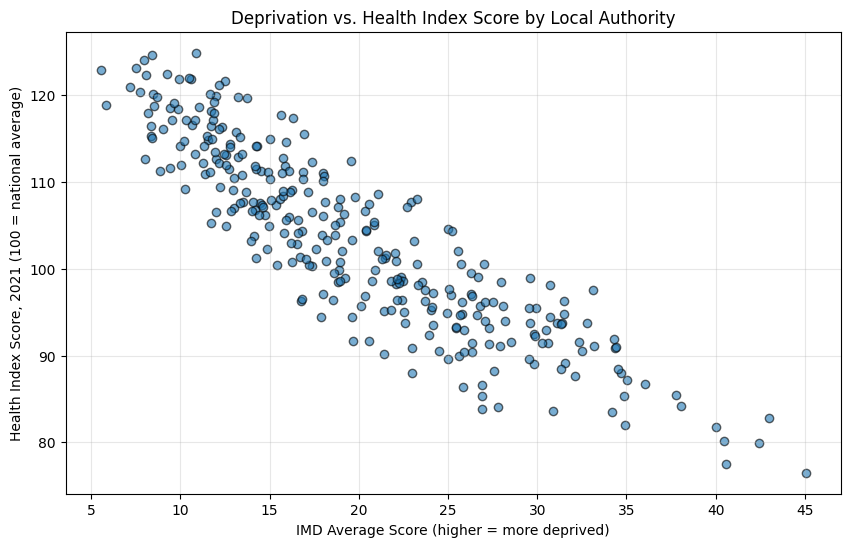

Correlation between deprivation and health score: -0.894


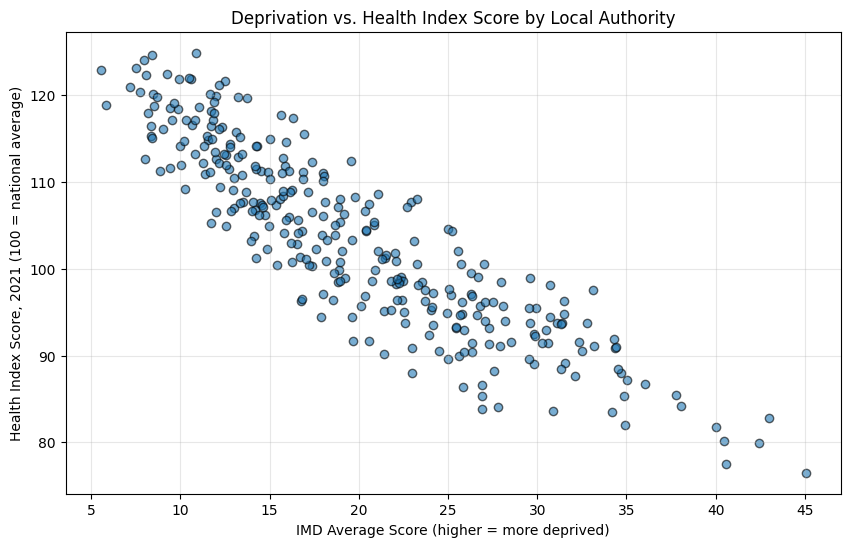

Correlation between deprivation and health score: -0.894


In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(merged['imd_avg_score'], merged['2021'], alpha=0.6, edgecolor='k')
plt.xlabel('IMD Average Score (higher = more deprived)')
plt.ylabel('Health Index Score, 2021 (100 = national average)')
plt.title('Deprivation vs. Health Index Score by Local Authority')
plt.grid(alpha=0.3)
plt.show()

# Quantify the relationship
correlation = merged['imd_avg_score'].corr(merged['2021'])
print(f"Correlation between deprivation and health score: {correlation:.3f}")

In [33]:
# Fit a simple trend line to find residuals (how far each point is from the "expected" health score)
import numpy as np

z = np.polyfit(merged['imd_avg_score'], merged['2021'], 1)
merged['predicted_health'] = np.polyval(z, merged['imd_avg_score'])
merged['residual'] = merged['2021'] - merged['predicted_health']

print("Best health OUTCOMES relative to their deprivation level (positive outliers):")
print(merged.nlargest(5, 'residual')[['area_name_health', 'imd_avg_score', '2021', 'residual']])

print("\nWorst health outcomes relative to their deprivation level (negative outliers):")
print(merged.nsmallest(5, 'residual')[['area_name_health', 'imd_avg_score', '2021', 'residual']])

Best health OUTCOMES relative to their deprivation level (positive outliers):
    area_name_health  imd_avg_score   2021   residual
58         Harrogate         10.897  124.9  10.956827
22              Eden         16.328  117.4   9.900623
170   Great Yarmouth         33.097   97.5   9.896779
23    South Lakeland         12.501  121.6   9.559948
81         High Peak         15.642  117.7   9.386695

Worst health outcomes relative to their deprivation level (negative outliers):
    area_name_health  imd_avg_score  2021   residual
167        Stevenage         19.695  91.7 -11.804484
91            Boston         22.967  88.0 -11.622307
153           Harlow         21.413  90.2 -11.266104
95     South Holland         17.896  94.4 -11.238969
221       Portsmouth         26.899  83.8 -11.157051
Best health OUTCOMES relative to their deprivation level (positive outliers):
    area_name_health  imd_avg_score   2021   residual
58         Harrogate         10.897  124.9  10.956827
22            

In [34]:
domains_to_load = ['Income', 'Employment', 'Education', 'Health', 'Crime', 'Barriers', 'Living']
domain_data = {}

for domain in domains_to_load:
    df = deprivation[domain]
    print(f"--- {domain} ---")
    print(df.columns.tolist()[:6])
    print()

--- Income ---
['Local Authority District code (2019)', 'Local Authority District name (2019)', 'Income - Average rank ', 'Income - Rank of average rank ', 'Income - Average score ', 'Income - Rank of average score ']

--- Employment ---
['Local Authority District code (2019)', 'Local Authority District name (2019)', 'Employment - Average rank ', 'Employment - Rank of average rank ', 'Employment - Average score ', 'Employment - Rank of average score ']

--- Education ---
['Local Authority District code (2019)', 'Local Authority District name (2019)', 'Education, Skills and Training - Average rank ', 'Education, Skills and Training - Rank of average rank ', 'Education, Skills and Training - Average score ', 'Education, Skills and Training - Rank of average score ']

--- Health ---
['Local Authority District code (2019)', 'Local Authority District name (2019)', 'Health Deprivation and Disability - Average rank ', 'Health Deprivation and Disability - Rank of average rank ', 'Health Depriv

In [35]:
# Map each sheet name to its exact column prefix and a clean short name
domain_map = {
    'Income': ('Income', 'income_score'),
    'Employment': ('Employment', 'employment_score'),
    'Education': ('Education, Skills and Training', 'education_score'),
    'Health': ('Health Deprivation and Disability', 'health_deprivation_score'),
    'Crime': ('Crime', 'crime_score'),
    'Barriers': ('Barriers to Housing and Services', 'barriers_score'),
    'Living': ('Living Environment', 'living_env_score')
}

for sheet_name, (prefix, clean_name) in domain_map.items():
    df = deprivation[sheet_name][['Local Authority District code (2019)', f'{prefix} - Average score ']].copy()
    df.columns = ['area_code', clean_name]
    merged = pd.merge(merged, df, on='area_code', how='left')

print(merged.shape)
print(merged.columns.tolist())
merged.head()

(304, 23)
['area_code', 'area_name_health', 'area_type', '2015', '2016', '2017', '2018', '2019', '2020', '2021', 'area_name_imd', 'imd_avg_score', 'imd_avg_rank', 'imd_pct_most_deprived', 'predicted_health', 'residual', 'income_score', 'employment_score', 'education_score', 'health_deprivation_score', 'crime_score', 'barriers_score', 'living_env_score']


,area_code,area_name_health,area_type,2015,2016,2017,2018,2019,2020,2021,...,imd_pct_most_deprived,predicted_health,residual,income_score,employment_score,education_score,health_deprivation_score,crime_score,barriers_score,living_env_score
0,E06000001,Hartlepool,LTLA,88.3,88.5,86.3,85.6,85.4,87.3,87.2,...,0.3621,85.301442,1.898558,0.228,0.185,30.255,0.869,0.566,14.242,6.943
1,E06000002,Middlesbrough,LTLA,83.3,82.5,82.7,80.9,79.7,79.1,80.2,...,0.4884,78.867137,1.332863,0.251,0.191,38.850,1.194,0.701,14.183,12.929
2,E06000003,Redcar and Cleveland,LTLA,96.6,98.0,97.9,96.2,95.7,92.1,92.5,...,0.2386,91.524552,0.975448,0.186,0.165,27.768,0.790,0.138,14.139,7.793
3,E06000004,Stockton-on-Tees,LTLA,92.2,94.1,93.1,92.1,95.1,96.1,94.8,...,0.2083,96.272862,-1.472862,0.164,0.135,24.786,0.684,-0.111,15.870,6.007
4,E06000005,Darlington,LTLA,96.4,95.3,95.1,96.3,98.2,94.8,94.7,...,0.1846,96.430665,-1.730665,0.153,0.128,27.402,0.532,0.558,11.942,8.800


(304, 23)
['area_code', 'area_name_health', 'area_type', '2015', '2016', '2017', '2018', '2019', '2020', '2021', 'area_name_imd', 'imd_avg_score', 'imd_avg_rank', 'imd_pct_most_deprived', 'predicted_health', 'residual', 'income_score', 'employment_score', 'education_score', 'health_deprivation_score', 'crime_score', 'barriers_score', 'living_env_score']


,area_code,area_name_health,area_type,2015,2016,2017,2018,2019,2020,2021,...,imd_pct_most_deprived,predicted_health,residual,income_score,employment_score,education_score,health_deprivation_score,crime_score,barriers_score,living_env_score
0,E06000001,Hartlepool,LTLA,88.3,88.5,86.3,85.6,85.4,87.3,87.2,...,0.3621,85.301442,1.898558,0.228,0.185,30.255,0.869,0.566,14.242,6.943
1,E06000002,Middlesbrough,LTLA,83.3,82.5,82.7,80.9,79.7,79.1,80.2,...,0.4884,78.867137,1.332863,0.251,0.191,38.850,1.194,0.701,14.183,12.929
2,E06000003,Redcar and Cleveland,LTLA,96.6,98.0,97.9,96.2,95.7,92.1,92.5,...,0.2386,91.524552,0.975448,0.186,0.165,27.768,0.790,0.138,14.139,7.793
3,E06000004,Stockton-on-Tees,LTLA,92.2,94.1,93.1,92.1,95.1,96.1,94.8,...,0.2083,96.272862,-1.472862,0.164,0.135,24.786,0.684,-0.111,15.870,6.007
4,E06000005,Darlington,LTLA,96.4,95.3,95.1,96.3,98.2,94.8,94.7,...,0.1846,96.430665,-1.730665,0.153,0.128,27.402,0.532,0.558,11.942,8.800


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define our predictors (the 7 domain scores) and target (2021 health score)
feature_cols = ['income_score', 'employment_score', 'education_score',
                 'health_deprivation_score', 'crime_score', 'barriers_score', 'living_env_score']

X = merged[feature_cols]
y = merged['2021'].astype(float)

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} local authorities")
print(f"Test set: {X_test.shape[0]} local authorities")

Training set: 243 local authorities
Test set: 61 local authorities
Training set: 243 local authorities
Test set: 61 local authorities


In [37]:
model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Evaluate on the test set
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} health-index points")
print(f"R² score: {r2:.3f}")

Mean Absolute Error: 3.37 health-index points
R² score: 0.833
Mean Absolute Error: 3.37 health-index points
R² score: 0.833


                     domain  importance
0              income_score    0.841649
4               crime_score    0.048012
3  health_deprivation_score    0.035416
2           education_score    0.031269
5            barriers_score    0.022101
6          living_env_score    0.011465
1          employment_score    0.010088


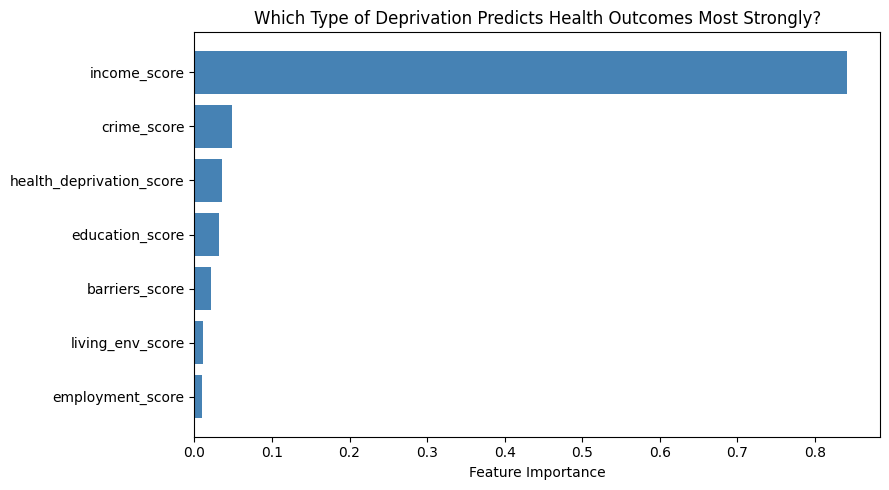

                     domain  importance
0              income_score    0.841649
4               crime_score    0.048012
3  health_deprivation_score    0.035416
2           education_score    0.031269
5            barriers_score    0.022101
6          living_env_score    0.011465
1          employment_score    0.010088


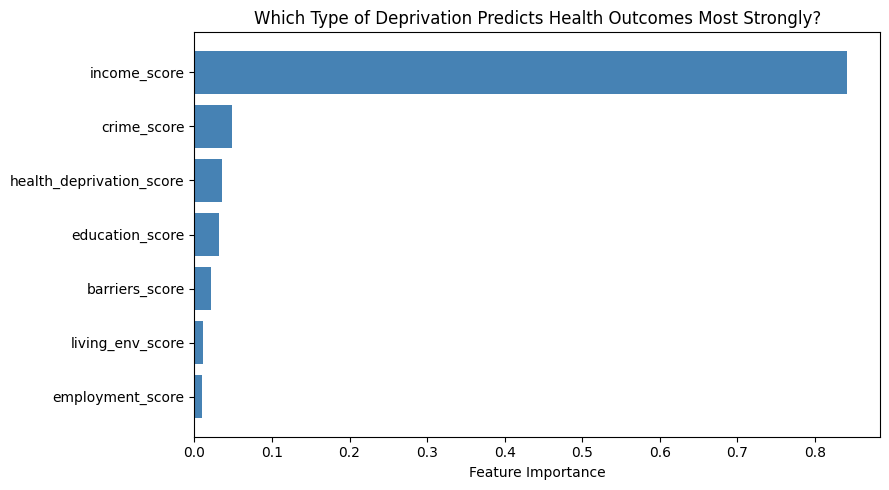

In [38]:
import pandas as pd

importances = pd.DataFrame({
    'domain': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

# Visualize it
plt.figure(figsize=(9, 5))
plt.barh(importances['domain'], importances['importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Which Type of Deprivation Predicts Health Outcomes Most Strongly?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [39]:
# Check correlations between the domain scores themselves
domain_corr = merged[feature_cols].corr()
print(domain_corr['income_score'].sort_values(ascending=False))

income_score                1.000000
employment_score            0.942942
health_deprivation_score    0.875820
education_score             0.745474
crime_score                 0.723142
living_env_score            0.364102
barriers_score             -0.139310
Name: income_score, dtype: float64
income_score                1.000000
employment_score            0.942942
health_deprivation_score    0.875820
education_score             0.745474
crime_score                 0.723142
living_env_score            0.364102
barriers_score             -0.139310
Name: income_score, dtype: float64


In [40]:
# More robust importance check: permutation importance
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42)

perm_importances = pd.DataFrame({
    'domain': feature_cols,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False)

print(perm_importances)

                     domain  importance
0              income_score    0.941411
4               crime_score    0.081704
3  health_deprivation_score    0.027079
5            barriers_score    0.023405
2           education_score    0.020051
1          employment_score    0.007584
6          living_env_score   -0.002240
                     domain  importance
0              income_score    0.941411
4               crime_score    0.081704
3  health_deprivation_score    0.027079
5            barriers_score    0.023405
2           education_score    0.020051
1          employment_score    0.007584
6          living_env_score   -0.002240


In [41]:
# Create a simplified feature set: combine highly correlated domains, keep distinct ones separate
merged['economic_cluster'] = merged[['income_score', 'employment_score', 'health_deprivation_score', 'education_score']].mean(axis=1)

X_simple = merged[['economic_cluster', 'crime_score', 'barriers_score', 'living_env_score']]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model2 = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print(f"Simplified model R²: {r2_score(y_test2, y_pred2):.3f}")
print(f"Simplified model MAE: {mean_absolute_error(y_test2, y_pred2):.2f}")

importances2 = pd.DataFrame({
    'domain': X_simple.columns,
    'importance': model2.feature_importances_
}).sort_values('importance', ascending=False)
print(importances2)

Simplified model R²: 0.826
Simplified model MAE: 3.41
             domain  importance
1       crime_score    0.560781
0  economic_cluster    0.359932
3  living_env_score    0.052561
2    barriers_score    0.026726
Simplified model R²: 0.826
Simplified model MAE: 3.41
             domain  importance
1       crime_score    0.560781
0  economic_cluster    0.359932
3  living_env_score    0.052561
2    barriers_score    0.026726


In [42]:
# Check correlation between crime and the economic cluster
print(merged[['economic_cluster', 'crime_score']].corr())

# Test stability: run the simplified model with several different random seeds
for seed in [0, 1, 42, 100, 2024]:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=seed)
    m = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=seed)
    m.fit(X_train_s, y_train_s)
    imp = dict(zip(X_simple.columns, m.feature_importances_))
    print(f"Seed {seed}: economic={imp['economic_cluster']:.2f}, crime={imp['crime_score']:.2f}, barriers={imp['barriers_score']:.2f}, living={imp['living_env_score']:.2f}")

                  economic_cluster  crime_score
economic_cluster          1.000000     0.486439
crime_score               0.486439     1.000000
Seed 0: economic=0.44, crime=0.48, barriers=0.03, living=0.06
Seed 1: economic=0.42, crime=0.50, barriers=0.02, living=0.06
Seed 42: economic=0.36, crime=0.56, barriers=0.03, living=0.05
Seed 100: economic=0.37, crime=0.56, barriers=0.02, living=0.05
Seed 2024: economic=0.53, crime=0.38, barriers=0.03, living=0.06
                  economic_cluster  crime_score
economic_cluster          1.000000     0.486439
crime_score               0.486439     1.000000
Seed 0: economic=0.44, crime=0.48, barriers=0.03, living=0.06
Seed 1: economic=0.42, crime=0.50, barriers=0.02, living=0.06
Seed 42: economic=0.36, crime=0.56, barriers=0.03, living=0.05
Seed 100: economic=0.37, crime=0.56, barriers=0.02, living=0.05
Seed 2024: economic=0.53, crime=0.38, barriers=0.03, living=0.06


In [43]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Scale features (necessary for Ridge, since coefficient size must be comparable across variables)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # using original 7-domain X, not the simplified cluster version
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train3, y_train3)
y_pred3 = ridge.predict(X_test3)

print(f"Ridge R²: {r2_score(y_test3, y_pred3):.3f}")
print(f"Ridge MAE: {mean_absolute_error(y_test3, y_pred3):.2f}")

ridge_importance = pd.DataFrame({
    'domain': feature_cols,
    'coefficient': ridge.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(ridge_importance)

Ridge R²: 0.851
Ridge MAE: 3.07
                     domain  coefficient
0              income_score    -4.773201
3  health_deprivation_score    -4.221041
4               crime_score    -3.100015
1          employment_score     3.083402
2           education_score    -2.352659
5            barriers_score    -1.162512
6          living_env_score    -0.205692
Ridge R²: 0.851
Ridge MAE: 3.07
                     domain  coefficient
0              income_score    -4.773201
3  health_deprivation_score    -4.221041
4               crime_score    -3.100015
1          employment_score     3.083402
2           education_score    -2.352659
5            barriers_score    -1.162512
6          living_env_score    -0.205692


In [44]:
# Check: does removing employment_score change things?
feature_cols_no_emp = [c for c in feature_cols if c != 'employment_score']
X_no_emp = merged[feature_cols_no_emp]
X_scaled_ne = scaler.fit_transform(X_no_emp)
X_train4, X_test4, y_train4, y_test4 = train_test_split(X_scaled_ne, y, test_size=0.2, random_state=42)

ridge2 = Ridge(alpha=1.0)
ridge2.fit(X_train4, y_train4)
y_pred4 = ridge2.predict(X_test4)

print(f"Ridge (no employment) R²: {r2_score(y_test4, y_pred4):.3f}")

ridge_importance2 = pd.DataFrame({
    'domain': feature_cols_no_emp,
    'coefficient': ridge2.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(ridge_importance2)

Ridge (no employment) R²: 0.845
                     domain  coefficient
2  health_deprivation_score    -3.601987
3               crime_score    -3.499758
0              income_score    -2.260848
1           education_score    -2.193887
4            barriers_score    -1.597878
5          living_env_score    -0.370437
Ridge (no employment) R²: 0.845
                     domain  coefficient
2  health_deprivation_score    -3.601987
3               crime_score    -3.499758
0              income_score    -2.260848
1           education_score    -2.193887
4            barriers_score    -1.597878
5          living_env_score    -0.370437


In [45]:
from sklearn.ensemble import GradientBoostingRegressor

X_gb = merged[feature_cols_no_emp]  # same 6 domains as our final Ridge model, for fair comparison
X_train5, X_test5, y_train5, y_test5 = train_test_split(X_gb, y, test_size=0.2, random_state=42)

gbm = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gbm.fit(X_train5, y_train5)
y_pred5 = gbm.predict(X_test5)

print(f"Gradient Boosting R²: {r2_score(y_test5, y_pred5):.3f}")
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test5, y_pred5):.2f}")

gbm_importance = pd.DataFrame({
    'domain': feature_cols_no_emp,
    'importance': gbm.feature_importances_
}).sort_values('importance', ascending=False)
print(gbm_importance)

Gradient Boosting R²: 0.851
Gradient Boosting MAE: 3.34
                     domain  importance
0              income_score    0.710910
3               crime_score    0.108958
2  health_deprivation_score    0.085735
1           education_score    0.047732
4            barriers_score    0.032180
5          living_env_score    0.014485
Gradient Boosting R²: 0.851
Gradient Boosting MAE: 3.34
                     domain  importance
0              income_score    0.710910
3               crime_score    0.108958
2  health_deprivation_score    0.085735
1           education_score    0.047732
4            barriers_score    0.032180
5          living_env_score    0.014485


In [46]:
from sklearn.model_selection import cross_val_score

ridge_final = Ridge(alpha=1.0)
X_final_scaled = scaler.fit_transform(merged[feature_cols_no_emp])

cv_scores = cross_val_score(ridge_final, X_final_scaled, y, cv=5, scoring='r2')

print("R² across 5 folds:", [f"{s:.3f}" for s in cv_scores])
print(f"Mean R²: {cv_scores.mean():.3f}  (± {cv_scores.std():.3f})")

R² across 5 folds: ['0.902', '0.801', '0.815', '0.762', '0.874']
Mean R²: 0.831  (± 0.050)
R² across 5 folds: ['0.902', '0.801', '0.815', '0.762', '0.874']
Mean R²: 0.831  (± 0.050)


**Geospatial Mapping**

In [47]:
!pip install geopandas --quiet

In [52]:
import geopandas as gpd

boundaries_url = "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/Local_Authority_Districts_April_2019_UK_BUC_2022/FeatureServer/0/query?where=1=1&outFields=*&f=geojson"

boundaries = gpd.read_file(boundaries_url)
print(boundaries.shape)
print(boundaries.columns.tolist())
boundaries.head()

(382, 12)
['OBJECTID', 'LAD19CD', 'LAD19NM', 'LAD19NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'Shape__Area', 'Shape__Length', 'GlobalID', 'geometry']


,OBJECTID,LAD19CD,LAD19NM,LAD19NMW,BNG_E,BNG_N,LONG,LAT,Shape__Area,Shape__Length,GlobalID,geometry
0,1,E06000001,Hartlepool,,447157,531476,-1.27023,54.6762,9.651231e+07,50488.387081,04419154-a30d-4803-ad36-adff535bdc4f,"POLYGON ((-1.17763 54.69919, -1.17398 54.69182..."
1,2,E06000002,Middlesbrough,,451141,516887,-1.21099,54.5447,5.522915e+07,35506.404054,8c58c819-b053-440b-a820-4f325831bae7,"POLYGON ((-1.28263 54.56528, -1.26256 54.57029..."
2,3,E06000003,Redcar and Cleveland,,464359,519597,-1.00611,54.5675,2.484090e+08,79150.715938,a28340e3-933d-4e5f-b0bb-db0141fd39f5,"POLYGON ((-1.14913 54.61433, -1.15462 54.6275,..."
3,4,E06000004,Stockton-on-Tees,,444937,518183,-1.30669,54.5569,2.052315e+08,87566.678920,45846d1d-0ddc-478c-9709-46a63608934f,"POLYGON ((-1.28263 54.56528, -1.27061 54.55602..."
4,5,E06000005,Darlington,,428029,515648,-1.56835,54.5353,1.988128e+08,91926.839545,073fde2a-793d-488d-8028-641cc746e271,"POLYGON ((-1.69693 54.53601, -1.70527 54.54917..."


In [53]:
# Merge the boundaries with our merged dataset (health + deprivation scores)
map_data = boundaries.merge(merged, left_on='LAD19CD', right_on='area_code', how='inner')

print(f"Matched {map_data.shape[0]} out of {merged.shape[0]} local authorities to boundaries")

Matched 304 out of 304 local authorities to boundaries


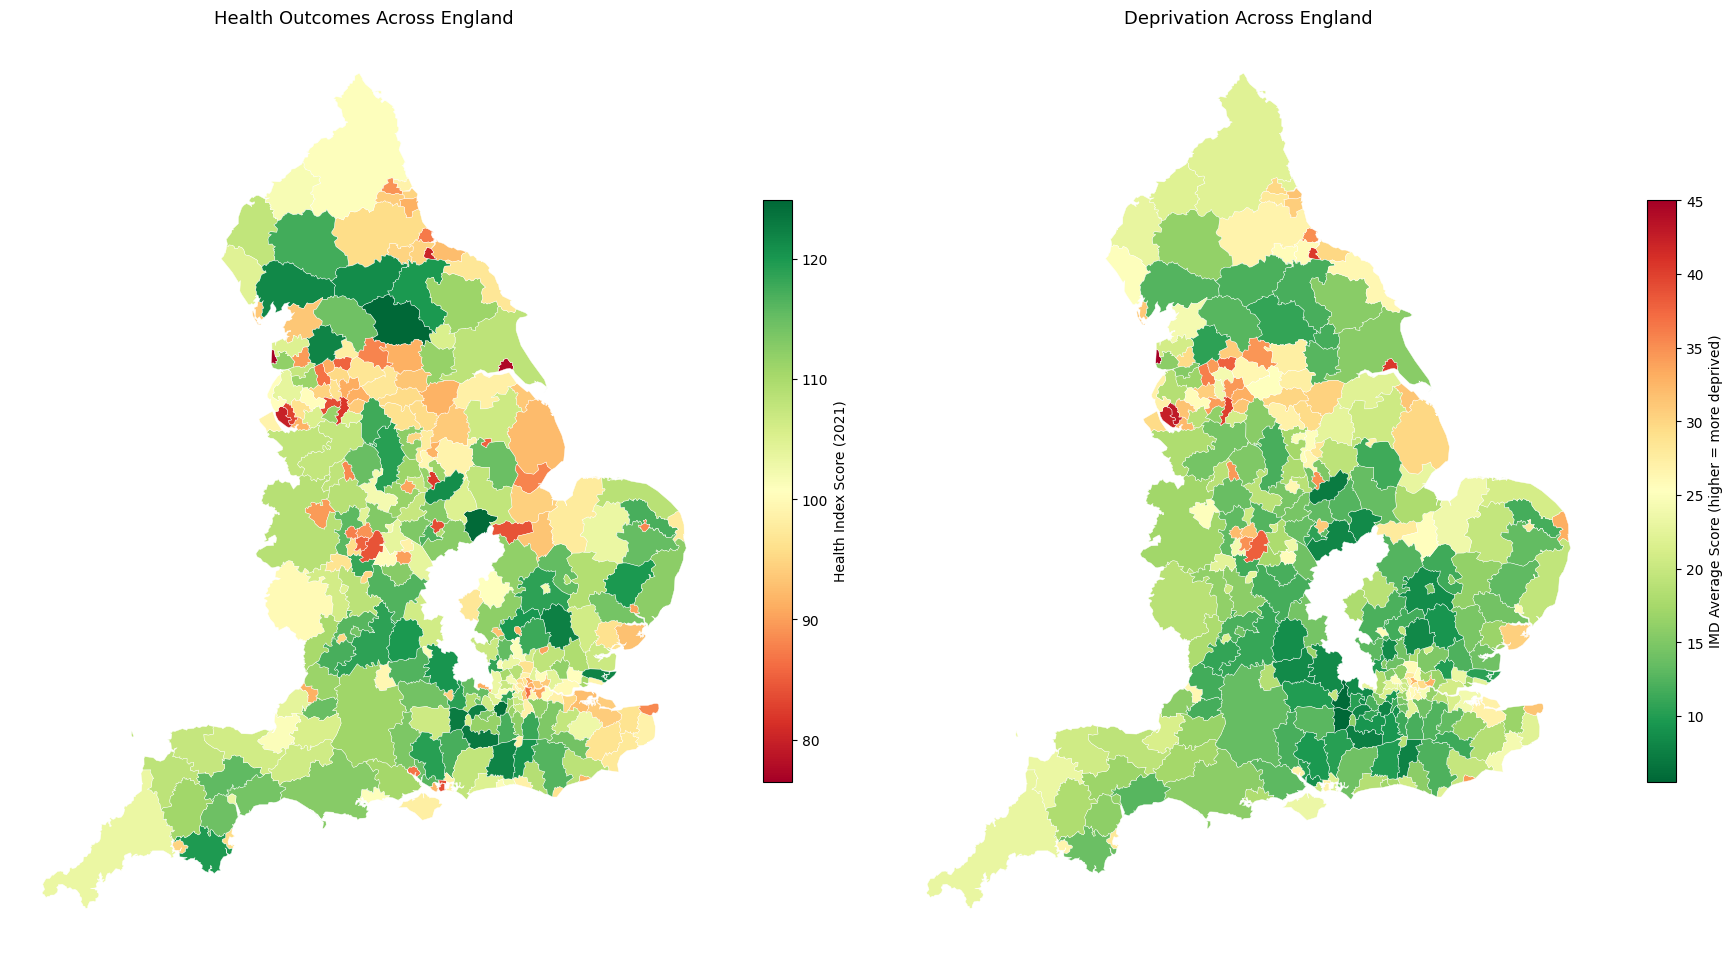

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Map 1: Health Index score
map_data.plot(column='2021', cmap='RdYlGn', legend=True, ax=axes[0],
               edgecolor='white', linewidth=0.3,
               legend_kwds={'label': 'Health Index Score (2021)', 'shrink': 0.6})
axes[0].set_title('Health Outcomes Across England', fontsize=13)
axes[0].axis('off')

# Map 2: Deprivation score
map_data.plot(column='imd_avg_score', cmap='RdYlGn_r', legend=True, ax=axes[1],
               edgecolor='white', linewidth=0.3,
               legend_kwds={'label': 'IMD Average Score (higher = more deprived)', 'shrink': 0.6})
axes[1].set_title('Deprivation Across England', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [56]:
# Most of the "missing" are Wales (W0...) and Scotland (S0...) — never part of our English-only analysis to begin with
missing_england_only = missing[missing['LAD19CD'].str.startswith('E')]
print(f"Missing England-only areas: {len(missing_england_only)}")
print(missing_england_only[['LAD19CD', 'LAD19NM']])

Missing England-only areas: 13
       LAD19CD                 LAD19NM
49   E06000053         Isles of Scilly
56   E07000004          Aylesbury Vale
57   E07000005                Chiltern
58   E07000006             South Bucks
59   E07000007                 Wycombe
172  E07000150                   Corby
173  E07000151                Daventry
174  E07000152   East Northamptonshire
175  E07000153               Kettering
176  E07000154             Northampton
177  E07000155  South Northamptonshire
178  E07000156          Wellingborough
284  E09000001          City of London


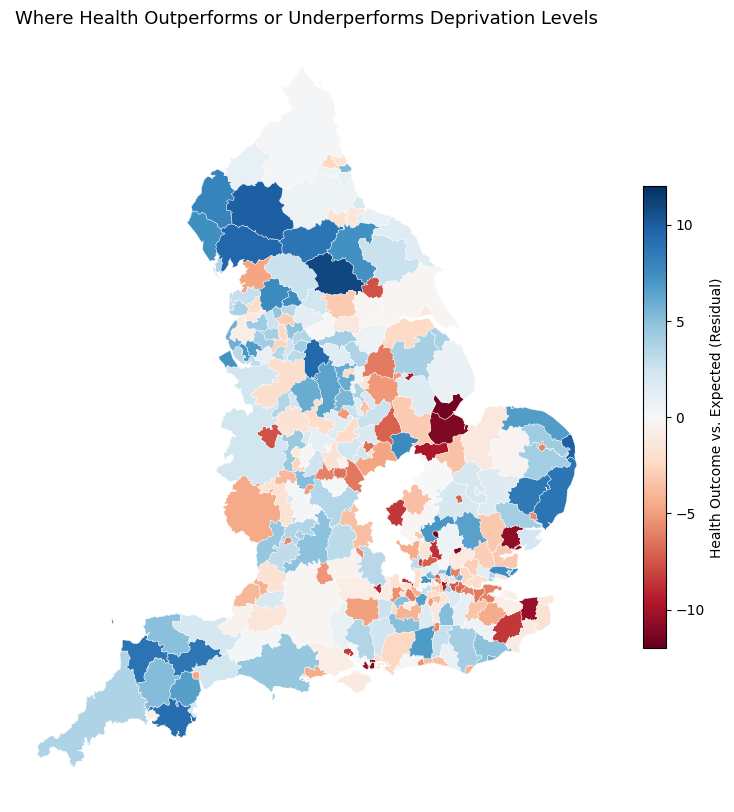

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

map_data.plot(column='residual', cmap='RdBu', legend=True, ax=ax,
               edgecolor='white', linewidth=0.3, vmin=-12, vmax=12,
               legend_kwds={'label': 'Health Outcome vs. Expected (Residual)', 'shrink': 0.6})
ax.set_title('Where Health Outperforms or Underperforms Deprivation Levels', fontsize=13)
ax.axis('off')
plt.show()

In [58]:
# Build the final export table
export_cols = [
    'area_code', 'area_name_health', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
    'imd_avg_score', 'imd_avg_rank', 'imd_pct_most_deprived',
    'income_score', 'employment_score', 'education_score',
    'health_deprivation_score', 'crime_score', 'barriers_score', 'living_env_score',
    'predicted_health', 'residual'
]

export_df = merged[export_cols].copy()

# Add lat/long from the boundaries file, useful for Power BI map visuals
coords = boundaries[['LAD19CD', 'LAT', 'LONG']].rename(columns={'LAD19CD': 'area_code'})
export_df = export_df.merge(coords, on='area_code', how='left')

# Rename year columns for Power BI friendliness (avoids any ambiguity with numeric column names)
export_df = export_df.rename(columns={
    '2015': 'health_2015', '2016': 'health_2016', '2017': 'health_2017',
    '2018': 'health_2018', '2019': 'health_2019', '2020': 'health_2020', '2021': 'health_2021',
    'area_name_health': 'area_name'
})

print(export_df.shape)
export_df.head()

(304, 23)


,area_code,area_name,health_2015,health_2016,health_2017,health_2018,health_2019,health_2020,health_2021,imd_avg_score,...,employment_score,education_score,health_deprivation_score,crime_score,barriers_score,living_env_score,predicted_health,residual,LAT,LONG
0,E06000001,Hartlepool,88.3,88.5,86.3,85.6,85.4,87.3,87.2,35.037,...,0.185,30.255,0.869,0.566,14.242,6.943,85.301442,1.898558,54.6762,-1.27023
1,E06000002,Middlesbrough,83.3,82.5,82.7,80.9,79.7,79.1,80.2,40.460,...,0.191,38.850,1.194,0.701,14.183,12.929,78.867137,1.332863,54.5447,-1.21099
2,E06000003,Redcar and Cleveland,96.6,98.0,97.9,96.2,95.7,92.1,92.5,29.792,...,0.165,27.768,0.790,0.138,14.139,7.793,91.524552,0.975448,54.5675,-1.00611
3,E06000004,Stockton-on-Tees,92.2,94.1,93.1,92.1,95.1,96.1,94.8,25.790,...,0.135,24.786,0.684,-0.111,15.870,6.007,96.272862,-1.472862,54.5569,-1.30669
4,E06000005,Darlington,96.4,95.3,95.1,96.3,98.2,94.8,94.7,25.657,...,0.128,27.402,0.532,0.558,11.942,8.800,96.430665,-1.730665,54.5353,-1.56835


In [59]:
# Save and download
export_df.to_csv('health_inequality_data.csv', index=False)

from google.colab import files
files.download('health_inequality_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

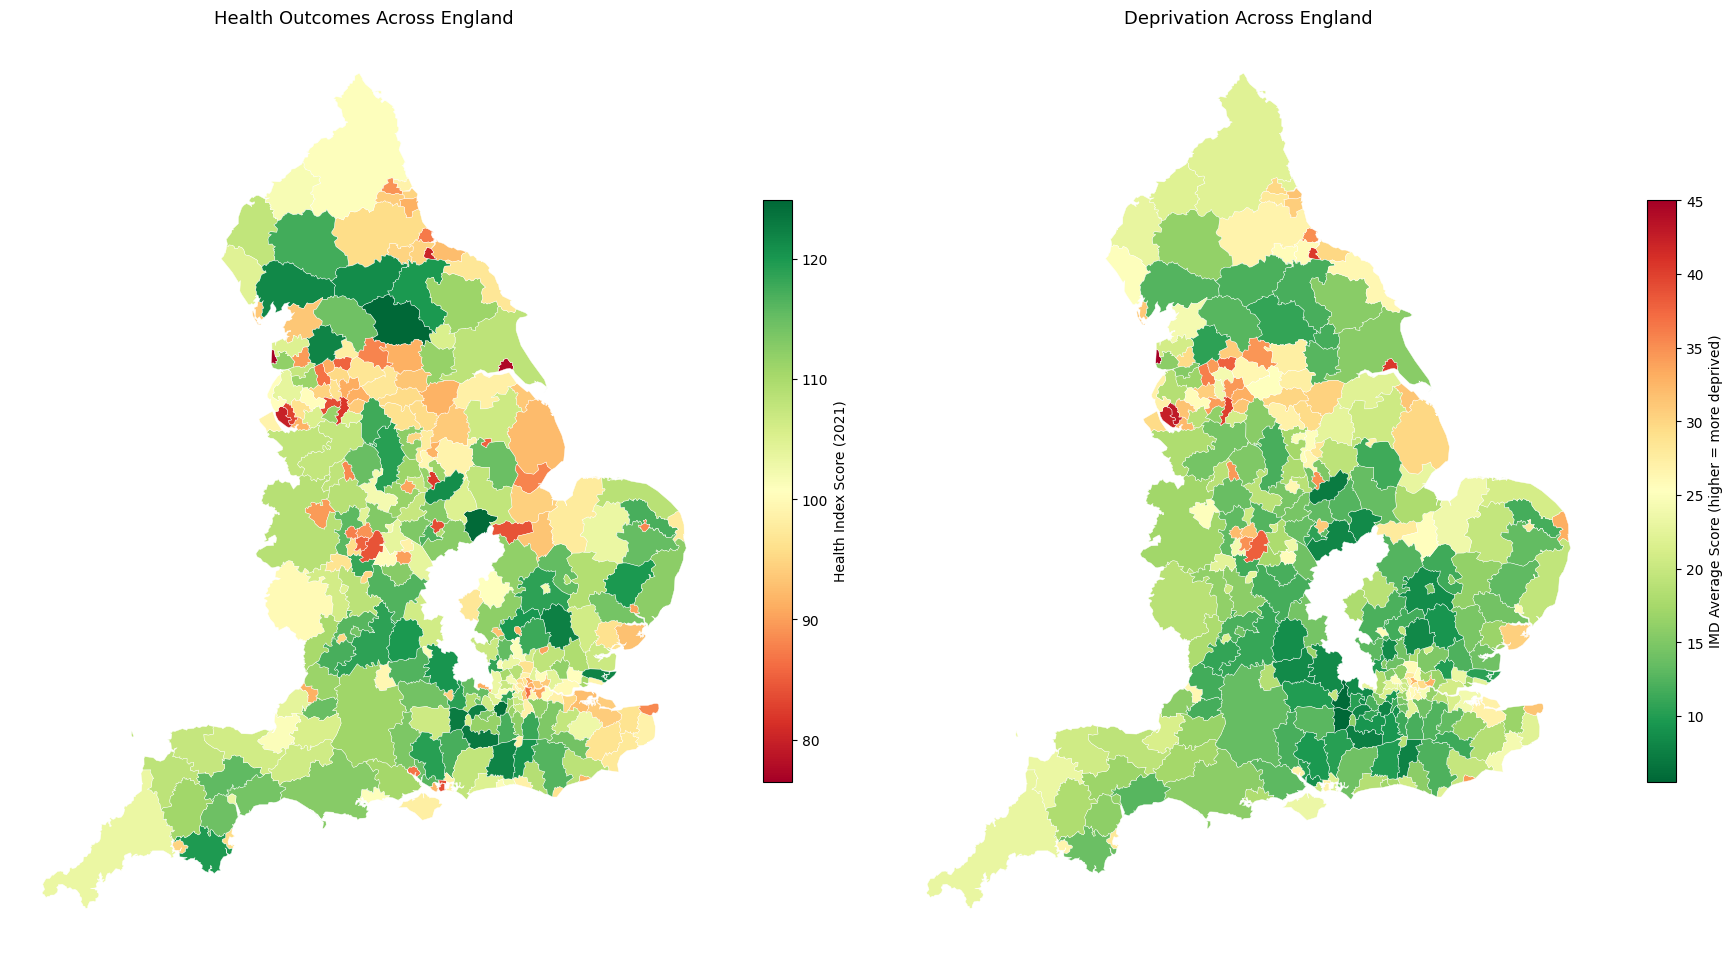

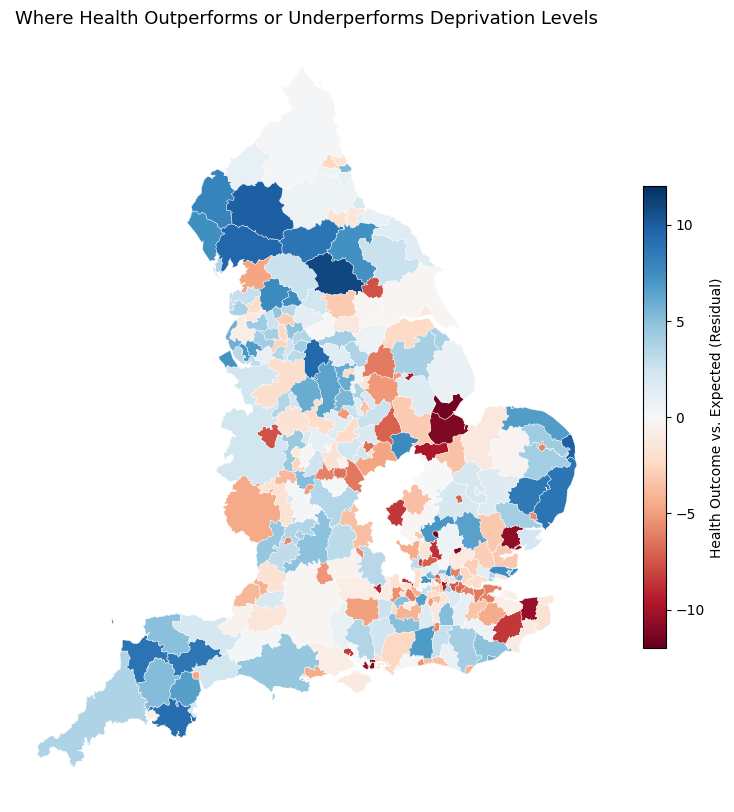

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
map_data.plot(column='2021', cmap='RdYlGn', legend=True, ax=axes[0], edgecolor='white', linewidth=0.3, legend_kwds={'label': 'Health Index Score (2021)', 'shrink': 0.6})
axes[0].set_title('Health Outcomes Across England', fontsize=13)
axes[0].axis('off')
map_data.plot(column='imd_avg_score', cmap='RdYlGn_r', legend=True, ax=axes[1], edgecolor='white', linewidth=0.3, legend_kwds={'label': 'IMD Average Score (higher = more deprived)', 'shrink': 0.6})
axes[1].set_title('Deprivation Across England', fontsize=13)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('health_deprivation_maps.png', dpi=200, bbox_inches='tight')

fig2, ax2 = plt.subplots(1, 1, figsize=(10, 10))
map_data.plot(column='residual', cmap='RdBu', legend=True, ax=ax2, edgecolor='white', linewidth=0.3, vmin=-12, vmax=12, legend_kwds={'label': 'Health Outcome vs. Expected (Residual)', 'shrink': 0.6})
ax2.set_title('Where Health Outperforms or Underperforms Deprivation Levels', fontsize=13)
ax2.axis('off')
plt.savefig('residual_map.png', dpi=200, bbox_inches='tight')

from google.colab import files
files.download('health_deprivation_maps.png')
files.download('residual_map.png')